<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Model_KD_Combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Model_KD_Combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model_KD_Combined
### Knowledge Distillation sweep — 2 Teachers × 2 Students × 2 Init Strategies = 8 Runs

| Role | Model |
|------|-------|
| Teacher A | VGG_Pretrained |
| Teacher B | ResNet_Pretrained |
| Student A | MobileNetV2 |
| Student B | MobileNetV3 |

**Per-run pipeline:**
1. Train student under KD (fine-tune from seed checkpoint OR from scratch)
2. Export FP32 ONNX → INT8 QDQ → compute NSE → flag quant-compatibility
3. Save record to `kd_combined_records.json` on Drive after every run

**Resume support:** re-running this notebook skips already-completed experiments automatically.  
Checkpoints that fail the NSE gate (`< 0.95`) are flagged and must not be passed to `Pipeline_Quantz`.

In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/stm32-thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place utils/ at: My Drive/stm32-thesis/utils/")

Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Imports ──────────────────────────────────────────────────────────
import os, json, math, time
import numpy as np
import pandas as pd
import torch

from pathlib import Path

from utils.dataset import prepare_dataset, get_loaders, get_test_loader
from utils.models  import (
    VGG_Pretrained, ResNet_Pretrained,
    VWW_MobileNetV2, VWW_MobileNetV3,
)
from utils.train import setup_device, set_seed, evaluate, train_kd

device = setup_device(seed=41)

Device: cuda


In [3]:
# ── Dataset ──────────────────────────────────────────────────────────
prepare_dataset()
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")
test_loader              = get_test_loader(batch_size=1)
print("✅ Dataset ready")

1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Train: 7000 | Val: 1500 | Batch: 64
Test: 1500 samples  ⚠️  Use only for final evaluation
✅ Dataset ready


In [4]:
# ── Config — edit here ───────────────────────────────────────────────
SAVE_DIR   = "/content/drive/My Drive/stm32-thesis/checkpoints"
EXPORT_DIR = Path("/content/drive/My Drive/stm32-thesis/exports")
SHARED_DIR = EXPORT_DIR / "shared"

# ── Teacher checkpoints ───────────────────────────────────────────────
TEACHER_VGG_CKPT    = f"{SAVE_DIR}/vgg_pretrained_seed_85.pth"
TEACHER_RESNET_CKPT = f"{SAVE_DIR}/resnet_pretrained_seed_85.pth"

# ── Student seed checkpoints (warm-start init) ────────────────────────
MV2_CKPT = f"{SAVE_DIR}/mobilenetv2_seed_74.pth"
MV3_CKPT = f"{SAVE_DIR}/mobilenetv3_seed_74.pth"

# ── Active teachers ───────────────────────────────────────────────────
ACTIVE_TEACHERS = {
    "vgg",        # VGG_Pretrained  — primary teacher
    "resnet",     # ResNet_Pretrained
}

# ── KD hyperparameters ────────────────────────────────────────────────
KD_TEMPERATURE = 4.0
KD_ALPHA       = 0.7
KD_EPOCHS      = 80
KD_WD          = 1e-4
KD_PATIENCE    = 20

# Fine-tune LR is per-student — do not unify these
# MobileNetV2: 3e-4 worked (gave +1.60%). 1e-3 destroyed the checkpoint.
# MobileNetV3: 3e-4 flatlined at +0.00%. Needs 1e-3 to escape local minimum.
KD_LR_FT_MV2 = 3e-4
KD_LR_FT_MV3 = 1e-3
KD_LR_SCR    = 1e-3   # scratch always 1e-3 regardless of student

# ── Quant gate ────────────────────────────────────────────────────────
NSE_THRESHOLD = 0.95

# ── Records JSON — resume support ─────────────────────────────────────
RECORDS_JSON = f"{SAVE_DIR}/kd_combined_records.json"

print("✅ Config loaded")
print(f"Active teachers : {ACTIVE_TEACHERS}")
print(f"NSE threshold   : {NSE_THRESHOLD}")

✅ Config loaded
Active teachers : {'resnet', 'vgg'}
NSE threshold   : 0.95


In [5]:
# ── Quantisation helpers ─────────────────────────────────────────────
!pip -q install onnx onnxruntime onnxruntime-tools

from utils.quantz import (
    generate_shared_test_files,
    export_onnx,
    save_calib_npz,
    quantize_int8,
    compute_nse,
)
print("✅ Quantisation helpers loaded from utils.quantz")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.7/212.7 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.1 MB/s eta 0:00:00
✅ Quantisation helpers loaded


In [6]:
# ── Pre-flight ───────────────────────────────────────────────────────
print("Checking teacher checkpoints...")
for name, path in [("VGG_Pretrained", TEACHER_VGG_CKPT),
                   ("ResNet_Pretrained", TEACHER_RESNET_CKPT)]:
    ok = os.path.exists(path)
    print(f"  {'✅' if ok else '⚠️ (inactive ok)'}  {name}: {path}")

print("\nChecking student seed checkpoints...")
for name, path in [("MobileNetV2", MV2_CKPT), ("MobileNetV3", MV3_CKPT)]:
    ok = os.path.exists(path)
    print(f"  {'✅' if ok else '❌'}  {name}: {path}")
    if not ok:
        raise FileNotFoundError(f"Missing seed checkpoint: {path}")

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
SHARED_INPUT_NPZ, SHARED_LABELS_NPZ = generate_shared_test_files(SHARED_DIR, test_loader)
print("\n✅ Pre-flight passed")

Checking teacher checkpoints...
  ✅  VGG_Pretrained: /content/drive/My Drive/stm32-thesis/checkpoints/vgg_pretrained_seed_85.pth
  ✅  ResNet_Pretrained: /content/drive/My Drive/stm32-thesis/checkpoints/resnet_pretrained_seed_85.pth

Checking student seed checkpoints...
  ✅  MobileNetV2: /content/drive/My Drive/stm32-thesis/checkpoints/mobilenetv2_seed_74.pth
  ✅  MobileNetV3: /content/drive/My Drive/stm32-thesis/checkpoints/mobilenetv3_seed_74.pth
    ⏭️  Shared test files exist

✅ Pre-flight passed


In [7]:
# ── Load active teachers + student baselines ─────────────────────────
teacher_vgg    = None
teacher_resnet = None
vgg_acc        = None
resnet_acc     = None

if "vgg" in ACTIVE_TEACHERS:
    teacher_vgg = VGG_Pretrained().to(device)
    teacher_vgg.load_state_dict(torch.load(TEACHER_VGG_CKPT, map_location=device))
    teacher_vgg.eval()
    for p in teacher_vgg.parameters(): p.requires_grad = False
    vgg_acc = evaluate(teacher_vgg, val_loader, device)
    print(f"Teacher VGG_Pretrained    : {vgg_acc*100:.2f}%")
else:
    print("⏭️  VGG teacher inactive")

if "resnet" in ACTIVE_TEACHERS:
    teacher_resnet = ResNet_Pretrained().to(device)
    teacher_resnet.load_state_dict(torch.load(TEACHER_RESNET_CKPT, map_location=device))
    teacher_resnet.eval()
    for p in teacher_resnet.parameters(): p.requires_grad = False
    resnet_acc = evaluate(teacher_resnet, val_loader, device)
    print(f"Teacher ResNet_Pretrained : {resnet_acc*100:.2f}%")
else:
    print("⏭️  ResNet teacher inactive")

# Student baselines
_tmp = VWW_MobileNetV2().to(device)
_tmp.load_state_dict(torch.load(MV2_CKPT, map_location=device))
baseline_mv2 = evaluate(_tmp, val_loader, device); del _tmp

_tmp = VWW_MobileNetV3().to(device)
_tmp.load_state_dict(torch.load(MV3_CKPT, map_location=device))
baseline_mv3 = evaluate(_tmp, val_loader, device); del _tmp

BASELINES = {"MobileNetV2": baseline_mv2, "MobileNetV3": baseline_mv3}

print(f"\nStudent MobileNetV2 baseline : {baseline_mv2*100:.2f}%")
print(f"Student MobileNetV3 baseline : {baseline_mv3*100:.2f}%")

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:03<00:00, 180MB/s]


Teacher VGG_Pretrained    : 89.07%
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


Teacher ResNet_Pretrained : 87.07%

Student MobileNetV2 baseline : 78.40%
Student MobileNetV3 baseline : 79.13%


In [8]:
# ── KD sweep — 2 teachers × 2 students × 2 init = 8 runs ────────────
# Resume: loads existing records from Drive, skips completed runs.

# ── Load existing progress ────────────────────────────────────────────
if os.path.exists(RECORDS_JSON):
    with open(RECORDS_JSON) as _f:
        records = json.load(_f)
    print(f"✅ Loaded {len(records)} existing records from Drive")
    for _r in records:
        print(f"   ↩️  {_r['run_key']:<25}  val_acc: {_r['val_acc_%']:.2f}%  "
              f"NSE: {_r['NSE']}  quant_ok: {_r['quant_ok']}")
else:
    records = []
    print("No existing records found — starting fresh")

print()

def _already_done(run_key):
    return any(r["run_key"] == run_key for r in records)

# ── Experiment definitions ────────────────────────────────────────────
# (run_key, teacher_key, teacher_model, student_name, student_cls,
#  init_strategy, student_seed_ckpt, lr)
EXPERIMENTS = [
    ("vgg_mv2_ft",         "vgg",    lambda: teacher_vgg,    "MobileNetV2", VWW_MobileNetV2, "ft",      MV2_CKPT, KD_LR_FT_MV2),
    ("vgg_mv2_scratch",    "vgg",    lambda: teacher_vgg,    "MobileNetV2", VWW_MobileNetV2, "scratch",  None,    KD_LR_SCR),
    ("vgg_mv3_ft",         "vgg",    lambda: teacher_vgg,    "MobileNetV3", VWW_MobileNetV3, "ft",      MV3_CKPT, KD_LR_FT_MV3),
    ("vgg_mv3_scratch",    "vgg",    lambda: teacher_vgg,    "MobileNetV3", VWW_MobileNetV3, "scratch",  None,    KD_LR_SCR),
    ("resnet_mv2_ft",      "resnet", lambda: teacher_resnet, "MobileNetV2", VWW_MobileNetV2, "ft",      MV2_CKPT, KD_LR_FT_MV2),
    ("resnet_mv2_scratch", "resnet", lambda: teacher_resnet, "MobileNetV2", VWW_MobileNetV2, "scratch",  None,    KD_LR_SCR),
    ("resnet_mv3_ft",      "resnet", lambda: teacher_resnet, "MobileNetV3", VWW_MobileNetV3, "ft",      MV3_CKPT, KD_LR_FT_MV3),
    ("resnet_mv3_scratch", "resnet", lambda: teacher_resnet, "MobileNetV3", VWW_MobileNetV3, "scratch",  None,    KD_LR_SCR),
]

for (run_key, teacher_key, teacher_fn, student_name,
     student_cls, init_strategy, seed_ckpt, lr) in EXPERIMENTS:

    # ── Skip inactive teacher ─────────────────────────────────────────
    if teacher_key not in ACTIVE_TEACHERS:
        print(f"⏭️  {run_key:<25} — teacher '{teacher_key}' inactive")
        continue

    # ── Skip if already done ──────────────────────────────────────────
    if _already_done(run_key):
        print(f"⏭️  {run_key:<25} — already done, skipping")
        continue

    teacher = teacher_fn()
    baseline = BASELINES[student_name]
    out_pth  = f"{SAVE_DIR}/{run_key}.pth"

    print(f"\n{'═'*60}")
    print(f"  {run_key}  |  {student_name}  |  init: {init_strategy}")
    print(f"  student baseline: {baseline*100:.2f}%  |  lr: {lr}")
    print(f"{'═'*60}")

    # ── Build student ─────────────────────────────────────────────────
    student = student_cls().to(device)
    if init_strategy == "ft":
        student.load_state_dict(torch.load(seed_ckpt, map_location=device))
        print(f"  Warm-start from seed checkpoint")
    else:
        print(f"  Random init (scratch)")

    # ── KD training ───────────────────────────────────────────────────
    t0 = time.time()
    val_acc, elapsed, kd_improved = train_kd(
        student      = student,
        teacher      = teacher,
        train_loader = train_loader,
        val_loader   = val_loader,
        device       = device,
        epochs       = KD_EPOCHS,
        lr           = lr,
        weight_decay = KD_WD,
        temperature  = KD_TEMPERATURE,
        alpha        = KD_ALPHA,
        patience     = KD_PATIENCE,
        save_path    = out_pth,
    )
    delta   = (val_acc - baseline) * 100
    print(f"\n  After KD     : {val_acc*100:.2f}%  delta: {delta:+.2f}%  ({elapsed:.1f} min)")
    if not kd_improved:
        print(f"  ⚠️  No improvement — saved checkpoint is the seed baseline")
    print(f"  Checkpoint   : {run_key}.pth")

    # ── Quantisation ──────────────────────────────────────────────────
    out_dir    = EXPORT_DIR / run_key
    out_dir.mkdir(parents=True, exist_ok=True)
    fp32_path  = out_dir / "model_fp32.onnx"
    calib_path = out_dir / "calib_train.npz"
    int8_path  = out_dir / "model_int8_qdq.onnx"

    # Reload best checkpoint saved by train_kd
    student_best = student_cls().to(device)
    student_best.load_state_dict(torch.load(out_pth, map_location=device))
    student_best.eval()

    export_onnx(student_best, fp32_path, device)
    save_calib_npz(calib_path, train_loader)
    try:
        quantize_int8(fp32_path, calib_path, int8_path)
        nse    = compute_nse(fp32_path, int8_path, SHARED_INPUT_NPZ)
        nse_ok = nse >= NSE_THRESHOLD
        quant_error = None
    except Exception as e:
        nse    = float("nan")
        nse_ok = False
        quant_error = str(e)
        print(f"    ⚠️  Quantisation failed: {e}")

    status = "✅ deploy" if nse_ok else "⛔ skip Pipeline_Quantz"
    print(f"  NSE          : {nse:.4f}  {status}")

    records.append({
        "run_key"      : run_key,
        "teacher"      : teacher_key,
        "student"      : student_name,
        "init"         : init_strategy,
        "baseline_%"   : round(baseline * 100, 2),
        "val_acc_%"    : round(val_acc * 100, 2),
        "delta_%"      : round(delta, 2),
        "NSE"          : round(nse, 4) if not math.isnan(nse) else None,
        "quant_ok"     : nse_ok,
        "quant_error"  : quant_error,
        "kd_improved"  : kd_improved,
        "ckpt"         : out_pth,
        "int8_path"    : str(int8_path) if nse_ok else None,
    })

    # ── Save progress immediately ──────────────────────────────────────
    with open(RECORDS_JSON, "w") as _f:
        json.dump(records, _f, indent=2)
    print(f"  💾 Progress saved ({len(records)} records total)")

    del student, student_best

print("\n\n✅ KD sweep complete (or all already done).")
print(f"   Records JSON: {RECORDS_JSON}")

No existing records found — starting fresh


════════════════════════════════════════════════════════════
  vgg_mv2_ft  |  MobileNetV2  |  init: ft
  student baseline: 78.40%  |  lr: 0.0003
════════════════════════════════════════════════════════════
  Warm-start from seed checkpoint
Initial student accuracy: 78.40%
Epoch   1/80 | Train 81.23% | Val 78.60% ✅
Epoch   2/80 | Train 81.00% | Val 78.73% ✅
Epoch   3/80 | Train 81.00% | Val 76.40%
Epoch   4/80 | Train 81.57% | Val 77.53%
Epoch   5/80 | Train 82.09% | Val 78.00%
Epoch   6/80 | Train 81.34% | Val 78.33%
Epoch   7/80 | Train 81.21% | Val 78.53%
Epoch   8/80 | Train 82.26% | Val 79.47% ✅
Epoch   9/80 | Train 81.34% | Val 78.07%
Epoch  10/80 | Train 81.84% | Val 80.07% ✅
Epoch  11/80 | Train 81.91% | Val 79.07%
Epoch  12/80 | Train 82.26% | Val 78.67%
Epoch  13/80 | Train 81.87% | Val 78.53%
Epoch  14/80 | Train 82.07% | Val 78.27%
Epoch  15/80 | Train 82.24% | Val 77.93%
Epoch  16/80 | Train 82.73% | Val 79.40%
Epoch  17/80 | Tra

/tmp/ipykernel_3200/2694300573.py:14: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


    ✅ FP32 ONNX saved


    ✅ Calib data saved (200 samples)


    ✅ INT8 QDQ ONNX saved
  NSE          : 0.9882  ✅ deploy
  💾 Progress saved (1 records total)

════════════════════════════════════════════════════════════
  vgg_mv2_scratch  |  MobileNetV2  |  init: scratch
  student baseline: 78.40%  |  lr: 0.001
════════════════════════════════════════════════════════════
  Random init (scratch)
Initial student accuracy: 50.00%
Epoch   1/80 | Train 59.71% | Val 61.47% ✅
Epoch   2/80 | Train 66.31% | Val 66.27% ✅
Epoch   3/80 | Train 68.56% | Val 67.67% ✅
Epoch   4/80 | Train 70.09% | Val 65.20%
Epoch   5/80 | Train 71.17% | Val 67.20%
Epoch   6/80 | Train 72.01% | Val 70.53% ✅
Epoch   7/80 | Train 72.87% | Val 72.33% ✅
Epoch   8/80 | Train 73.36% | Val 74.47% ✅
Epoch   9/80 | Train 73.66% | Val 74.67% ✅
Epoch  10/80 | Train 74.33% | Val 74.20%
Epoch  11/80 | Train 74.90% | Val 73.00%
Epoch  12/80 | Train 75.36% | Val 73.93%
Epoch  13/80 | Train 75.66% | Val 72.93%
Epoch  14/80 | Train 75.93% | Val 73.80%
Epoch  15/80 | Train 76.30% | Val 76.53% ✅

...

    ✅ INT8 QDQ ONNX saved
  NSE          : 0.9919  ✅ deploy
  💾 Progress saved (6 records total)

════════════════════════════════════════════════════════════
  resnet_mv3_ft  |  MobileNetV3  |  init: ft
  student baseline: 79.13%  |  lr: 0.001
════════════════════════════════════════════════════════════
  Warm-start from seed checkpoint
Initial student accuracy: 79.13%
Epoch   1/80 | Train 79.61% | Val 76.27%
Epoch   2/80 | Train 80.04% | Val 75.53%
Epoch   3/80 | Train 79.64% | Val 77.80%
Epoch   4/80 | Train 80.39% | Val 75.07%
Epoch   5/80 | Train 80.31% | Val 75.47%
Epoch   6/80 | Train 79.31% | Val 76.73%
Epoch   7/80 | Train 80.56% | Val 78.00%
Epoch   8/80 | Train 80.56% | Val 75.80%
Epoch   9/80 | Train 80.64% | Val 76.27%
Epoch  10/80 | Train 80.70% | Val 77.07%
Epoch  11/80 | Train 80.29% | Val 77.80%
Epoch  12/80 | Train 80.73% | Val 77.33%
Epoch  13/80 | Train 81.80% | Val 77.60%
Epoch  14/80 | Train 81.20% | Val 76.00%
Epoch  15/80 | Train 81.00% | Val 77.80%
Epoch  16/80

    ✅ Calib data saved (200 samples)


    ✅ INT8 QDQ ONNX saved
  NSE          : 0.9801  ✅ deploy
  💾 Progress saved (7 records total)

════════════════════════════════════════════════════════════
  resnet_mv3_scratch  |  MobileNetV3  |  init: scratch
  student baseline: 79.13%  |  lr: 0.001
════════════════════════════════════════════════════════════
  Random init (scratch)
Initial student accuracy: 50.00%
Epoch   1/80 | Train 59.93% | Val 59.67% ✅
Epoch   2/80 | Train 65.77% | Val 64.47% ✅
Epoch   3/80 | Train 67.91% | Val 68.60% ✅
Epoch   4/80 | Train 69.74% | Val 68.00%
Epoch   5/80 | Train 70.60% | Val 71.40% ✅
Epoch   6/80 | Train 71.61% | Val 71.40%
Epoch   7/80 | Train 72.29% | Val 70.53%
Epoch   8/80 | Train 72.59% | Val 71.07%
Epoch   9/80 | Train 73.56% | Val 72.53% ✅
Epoch  10/80 | Train 74.27% | Val 71.80%
Epoch  11/80 | Train 75.19% | Val 71.73%
Epoch  12/80 | Train 74.70% | Val 73.73% ✅
Epoch  13/80 | Train 75.79% | Val 72.73%
Epoch  14/80 | Train 75.41% | Val 73.67%
Epoch  15/80 | Train 76.09% | Val 75.27% 

    ✅ Calib data saved (200 samples)


    ✅ INT8 QDQ ONNX saved
  NSE          : 0.9824  ✅ deploy
  💾 Progress saved (8 records total)


✅ KD sweep complete (or all already done).
   Records JSON: /content/drive/My Drive/stm32-thesis/checkpoints/kd_combined_records.json


In [9]:
# ── Results table ────────────────────────────────────────────────────
# Reload from JSON so this cell works even across sessions
if os.path.exists(RECORDS_JSON):
    with open(RECORDS_JSON) as _f:
        records = json.load(_f)

df = pd.DataFrame(records)
df = df.sort_values(["student", "teacher", "init"]).reset_index(drop=True)

W = 95
print("=" * W)
print("KNOWLEDGE DISTILLATION RESULTS")
print("=" * W)

display_cols = ["run_key", "teacher", "student", "init",
                "baseline_%", "val_acc_%", "delta_%", "NSE", "quant_ok"]
print(df[display_cols].to_string(index=False))
print("=" * W)

# ── Per-student summary ───────────────────────────────────────────────
for student in ["MobileNetV2", "MobileNetV3"]:
    sub = df[df["student"] == student]
    if sub.empty: continue
    baseline = sub["baseline_%"].iloc[0]
    print(f"\n{student} (baseline: {baseline:.2f}%)")
    print(f"  {'Run':<25} {'Val Acc':>9}  {'Delta':>8}  {'NSE':>7}  Status")
    print(f"  {'-'*65}")
    for _, row in sub.iterrows():
        nse_str = f"{row['NSE']:.4f}" if row["NSE"] is not None else "  ERROR"
        gate    = "✅" if row["quant_ok"] else "⛔"
        print(f"  {row['run_key']:<25} {row['val_acc_%']:>8.2f}%  "
              f"{row['delta_%']:>+7.2f}%  {nse_str}  {gate}")

# ── NSE gate summary ──────────────────────────────────────────────────
print(f"\n{'─'*W}")
print("Quantisation gate (NSE ≥ 0.95):")
for _, row in df.iterrows():
    gate    = "✅ PASS — safe for Pipeline_Quantz" if row["quant_ok"] else "⛔ FAIL — exclude from Pipeline_Quantz"
    nse_str = f"{row['NSE']:.4f}" if row["NSE"] is not None else "ERROR"
    print(f"  {row['run_key']:<25}  NSE={nse_str}  {gate}")

# ── Best per student (quant-compatible only) ──────────────────────────
print(f"\n🏆 Best per student (quant-compatible only):")
deployable = df[df["quant_ok"] == True]
if len(deployable) == 0:
    print("  ⚠️  No quant-compatible checkpoints found.")
else:
    for student in ["MobileNetV2", "MobileNetV3"]:
        sub = deployable[deployable["student"] == student]
        if sub.empty:
            print(f"  {student}: no deployable checkpoint"); continue
        best = sub.loc[sub["val_acc_%"].idxmax()]
        print(f"  {student}: {best['run_key']:<25}  "
              f"{best['val_acc_%']:.2f}%  (delta {best['delta_%']:+.2f}%  NSE={best['NSE']:.4f})")

# ── Deployable list ───────────────────────────────────────────────────
print(f"\n📋 Deployable checkpoints (safe to pass to Pipeline_Quantz):")
dep_cols = ["run_key", "student", "init", "val_acc_%", "NSE", "int8_path", "ckpt"]
deployable_df = df[df["quant_ok"] == True][dep_cols]
if len(deployable_df) == 0:
    print("  None")
else:
    print(deployable_df.to_string(index=False))

KNOWLEDGE DISTILLATION RESULTS
           run_key teacher     student    init  baseline_%  val_acc_%  delta_%    NSE  quant_ok
     resnet_mv2_ft  resnet MobileNetV2      ft       78.40      79.20     0.80 0.9808      True
resnet_mv2_scratch  resnet MobileNetV2 scratch       78.40      78.53     0.13 0.9919      True
        vgg_mv2_ft     vgg MobileNetV2      ft       78.40      80.07     1.67 0.9882      True
   vgg_mv2_scratch     vgg MobileNetV2 scratch       78.40      79.53     1.13 0.9874      True
     resnet_mv3_ft  resnet MobileNetV3      ft       79.13      79.13     0.00 0.9801      True
resnet_mv3_scratch  resnet MobileNetV3 scratch       79.13      79.27     0.13 0.9824      True
        vgg_mv3_ft     vgg MobileNetV3      ft       79.13      79.13     0.00 0.9900      True
   vgg_mv3_scratch     vgg MobileNetV3 scratch       79.13      79.53     0.40 0.9902      True

MobileNetV2 (baseline: 78.40%)
  Run                         Val Acc     Delta      NSE  Status
  ------

/tmp/ipykernel_3200/2155412329.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3200/2155412329.py:52: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3200/2155412329.py:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_3200/2155412329.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=150)
/tmp/ipykernel_3200/2155412329.py:54: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/d

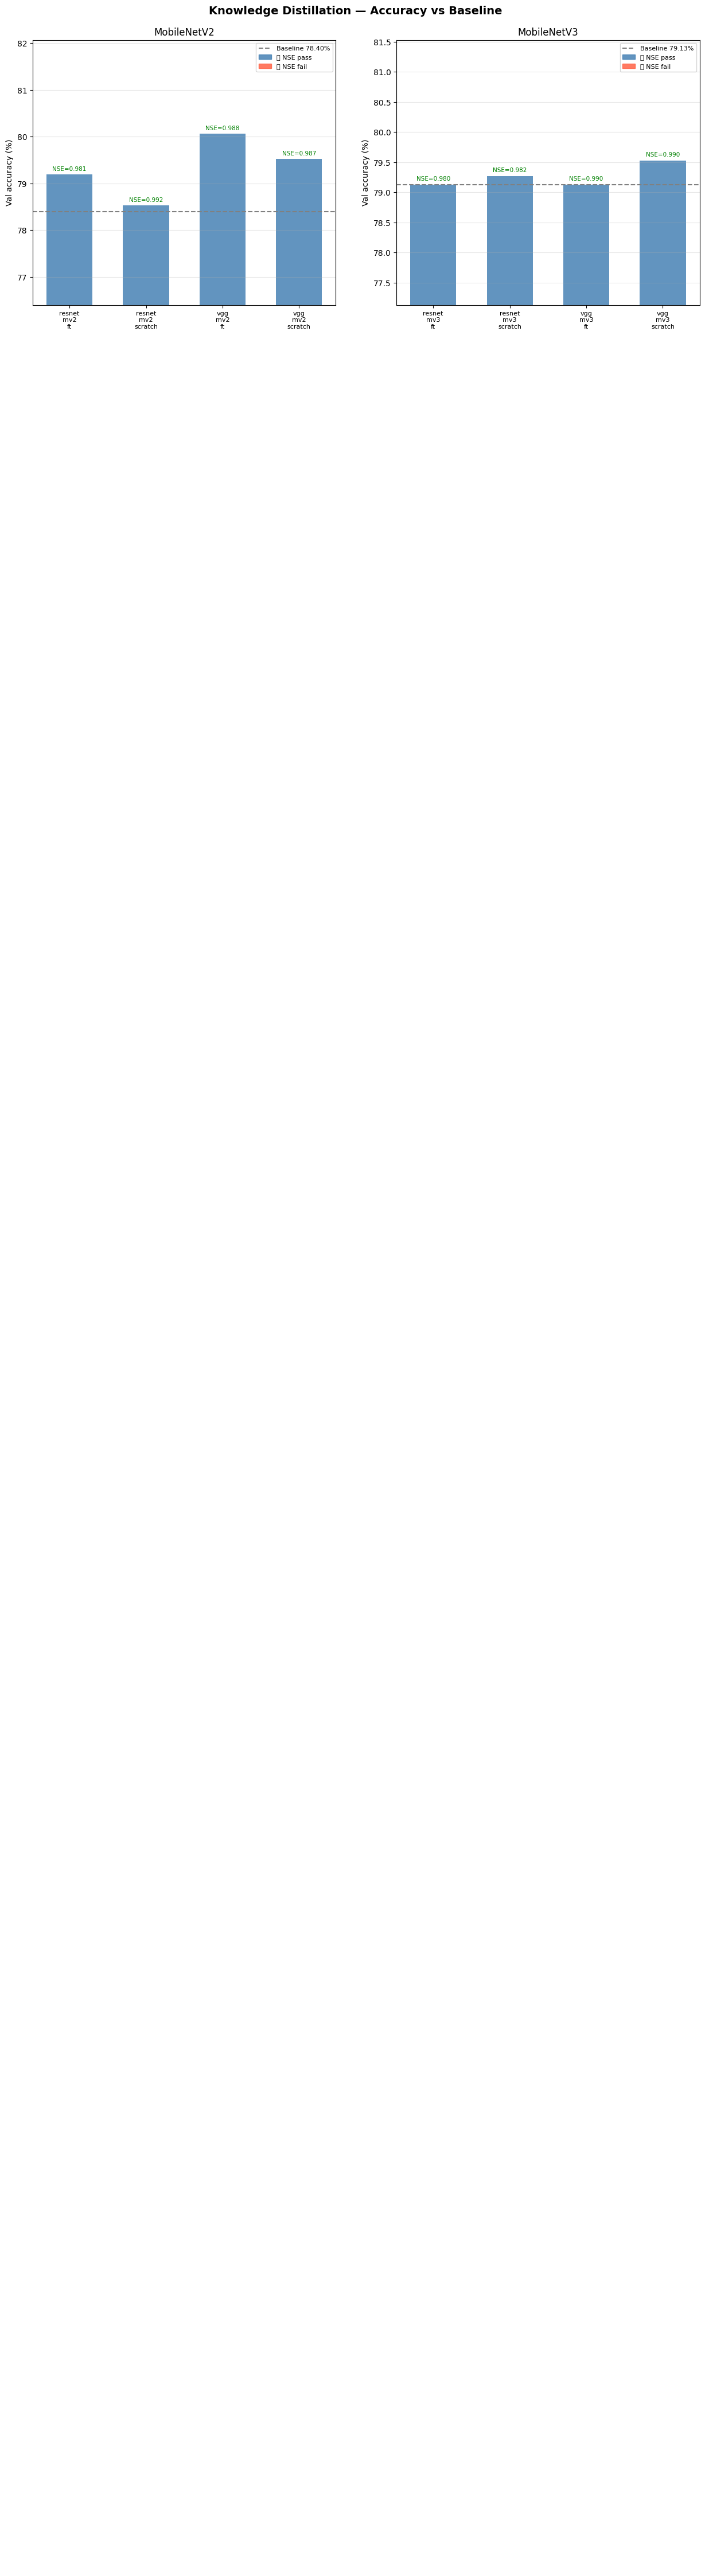

✅ Chart saved → /content/drive/My Drive/stm32-thesis/kd_results_chart.png


In [10]:
# ── Comparison chart — KD results vs baseline ────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

if os.path.exists(RECORDS_JSON):
    with open(RECORDS_JSON) as _f:
        records = json.load(_f)
df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Knowledge Distillation — Accuracy vs Baseline", fontsize=14, fontweight="bold")

for ax, student in zip(axes, ["MobileNetV2", "MobileNetV3"]):
    sub      = df[df["student"] == student].sort_values(["teacher", "init"])
    baseline = sub["baseline_%"].iloc[0] if len(sub) > 0 else 0

    run_labels = sub["run_key"].tolist()
    val_accs   = sub["val_acc_%"].tolist()
    quant_ok   = sub["quant_ok"].tolist()
    nses       = sub["NSE"].tolist()

    x      = np.arange(len(run_labels))
    colors = ["steelblue" if ok else "tomato" for ok in quant_ok]
    bars   = ax.bar(x, val_accs, color=colors, alpha=0.85, width=0.6)

    ax.axhline(baseline, color="gray", linestyle="--", linewidth=1.5,
               label=f"Baseline {baseline:.2f}%")

    # Annotate bars with NSE
    for i, (bar, nse, ok) in enumerate(zip(bars, nses, quant_ok)):
        nse_str = f"NSE={nse:.3f}" if nse is not None else "err"
        color   = "green" if ok else "red"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                nse_str, ha="center", va="bottom", fontsize=7.5, color=color)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f"{val_accs[i]:.2f}%", ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")

    pass_patch = mpatches.Patch(color="steelblue", alpha=0.85, label="✅ NSE pass")
    fail_patch = mpatches.Patch(color="tomato",    alpha=0.85, label="⛔ NSE fail")
    ax.legend(handles=[ax.get_legend_handles_labels()[0][0], pass_patch, fail_patch],
              fontsize=8)

    ax.set_title(f"{student}")
    ax.set_xticks(x)
    ax.set_xticklabels([l.replace("_", "\n") for l in run_labels], fontsize=8)
    ax.set_ylabel("Val accuracy (%)")
    ax.set_ylim(min(val_accs + [baseline]) - 2, max(val_accs + [baseline]) + 2)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plot_path = "/content/drive/My Drive/stm32-thesis/kd_results_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"✅ Chart saved → {plot_path}")

## Next steps

### ✅ Checkpoints safe for `Pipeline_Quantz`
Use the **deployable checkpoint list** printed above. Only pass `.pth` files where `quant_ok = True`.

### 🔁 Resume / re-run
- **Skip all done runs:** just re-run the sweep cell — completed runs are skipped automatically
- **Force one specific run:** delete its entry from `kd_combined_records.json` on Drive, then re-run
- **Force everything:** delete `kd_combined_records.json` entirely

### ⚙️ Enabling ResNet teacher
Set `ACTIVE_TEACHERS = {"vgg", "resnet"}` in the config cell.  
ResNet teacher runs are included in the sweep but skipped when `"resnet"` is not active.

> **⚠️ Deployment note:** KD val accuracy gains (+0.4% to +1.67%) do not reliably survive INT8 quantization. On STM32 INT8, KD students perform at or below baseline. KD is retained as a training technique but makes no deployment efficiency claim. Runs where `kd_improved=False` produced checkpoints identical to the seed baseline — these should not be labelled as KD-trained models in the thesis.